# Working with complicated dataset

Your name: Jake Crumley

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [88]:
### Your code here . . .
import pandas as pd
link = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv'

In [89]:
my_columns = ['subject acc.ver', '% identity', 'alignment length', 'mismatches', 'gap opens', 'q. start', 'q. end', 's. start', 's. end', 'evalue', 'bit score', '% positives', 'bonds', 'publications', 'query acc.ver']
data = pd.read_csv(link,
                   skiprows = 7,
                   names = my_columns,
                   na_values = '-'
                   )

In [90]:
data.head()

,subject acc.ver,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,query acc.ver
YP_220550.1,NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9.0,NaN
YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47.0,NaN
YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13.0,NaN
YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41.0,NaN
YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3.0,NaN


In [91]:
data = data.drop('query acc.ver', axis = 1)

In [92]:
data = data.set_index('subject acc.ver')

In [93]:
data.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3.0


### Question 2
What is the average number of publications?

In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % identity        100 non-null    float64
 1   alignment length  100 non-null    int64  
 2   mismatches        100 non-null    int64  
 3   gap opens         100 non-null    int64  
 4   q. start          100 non-null    int64  
 5   q. end            100 non-null    int64  
 6   s. start          100 non-null    int64  
 7   s. end            100 non-null    int64  
 8   evalue            100 non-null    int64  
 9   bit score         100 non-null    int64  
 10  % positives       100 non-null    float64
 11  bonds             100 non-null    object 
 12  publications      97 non-null     float64
dtypes: float64(3), int64(9), object(1)
memory usage: 10.9+ KB


In [95]:
### Your code here . . .
pubs = data['publications'].mean()
print(pubs)

26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [96]:
data['bonds'] = pd.to_numeric(data['bonds'].str.replace(',', ''), errors='coerce')

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % identity        100 non-null    float64
 1   alignment length  100 non-null    int64  
 2   mismatches        100 non-null    int64  
 3   gap opens         100 non-null    int64  
 4   q. start          100 non-null    int64  
 5   q. end            100 non-null    int64  
 6   s. start          100 non-null    int64  
 7   s. end            100 non-null    int64  
 8   evalue            100 non-null    int64  
 9   bit score         100 non-null    int64  
 10  % positives       100 non-null    float64
 11  bonds             100 non-null    int64  
 12  publications      97 non-null     float64
dtypes: float64(3), int64(10)
memory usage: 10.9+ KB


In [106]:
### Your code here . . .
subs = data[data['bonds'] > 15000].index
subs

Index(['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1',
       '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1',
       'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1',
       'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1',
       'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1',
       'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1',
       'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1',
       'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1',
       'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1'],
      dtype='object', name='subject acc.ver')

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

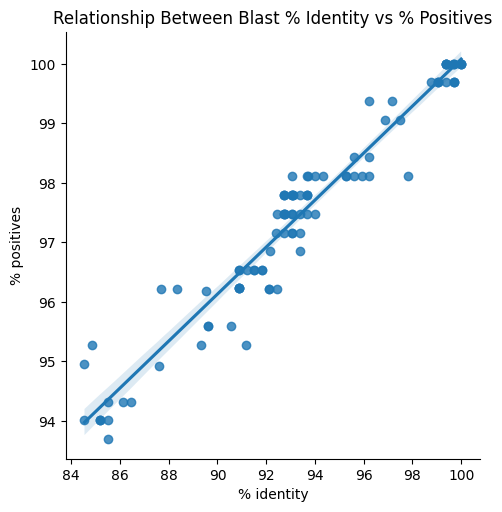

In [110]:
### Your code here . . .
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(data, x = '% identity', y = '% positives')
plt.title('Relationship Between Blast % Identity vs % Positives');

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [115]:
### Your code here . . .
new_link = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv'
proteins = pd.read_csv(new_link,
                   header = 0,
                   na_values = '-'
                   )
proteins.drop(columns = ['Unnamed: 0'], inplace = True)
proteins.head()

,Protein,Source
0,NP_904328.1,RefSeq
1,YP_220563.1,GenPept
2,YP_002791042.1,GenPept
3,YP_001686698.1,GenPept
4,YP_009112408.1,GenPept


In [120]:
updated_data = data.join(proteins.set_index('Protein'), how = 'left')
updated_data

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318,23,0,1,318,1,318,0,551,97.48,17348,6.0,NaN
ASP44815.1,93.375,317,21,0,1,317,1,317,0,551,96.85,7105,19.0,NaN
YP_009414156.1,84.543,317,49,0,1,317,1,317,0,551,94.01,18940,37.0,GenPept
